In [1]:
import os
import cv2
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = '/content/drive/MyDrive/image datazset'

In [3]:
X = []
y = []

In [4]:
for file in sorted(os.listdir(data)):
    if file.endswith('.jpg'):
        filepath = os.path.join(data, file)
        label = int(file.split('_')[1].split('.')[0])
        img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (92, 112))
        X.append(img.flatten())
        y.append(label)

In [5]:
X = np.array(X)
y = np.array(y)

In [6]:
X.shape

(410, 10304)

In [7]:
y.shape

(410,)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [9]:
lda = LinearDiscriminantAnalysis(n_components=40)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

In [10]:
clf = SVC(kernel='linear')
clf.fit(X_train_lda, y_train)
y_pred = clf.predict(X_test_lda)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.975609756097561


In [12]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      0.67      0.80         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      0.67      0.80         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       0.75      1.00      0.86         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00      1.00         3
          17       1.00      1.00      1.00         3
          18       1.00    

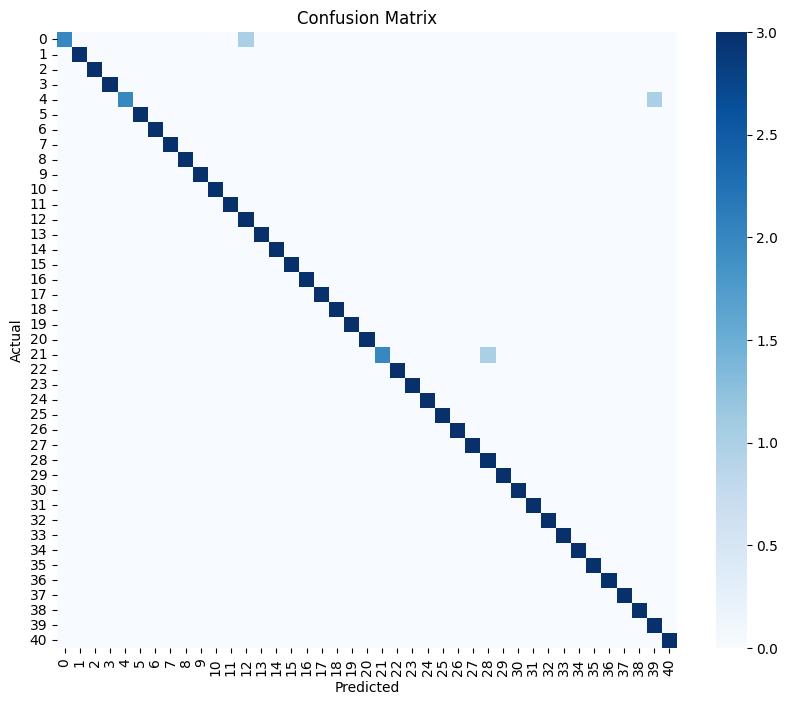

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
